<img src="logo_UNSAM.jpg" align="right" width="120" /> 
<br><br><br><br>
<div style="text-align: center;">

### Analisis y procesamiento de señales 1C 2026
# Trabajo Práctico Nº6

### Melanie amicucci

<br>
</div>

# Consigna

Dado las siguientes ecuaciones en diferencias de los siguientes sistemas, que representan un filtro de media móvil:

a) $y(n) = x(n-3) + x(n-2) + x(n-1) + x(n)$

b) $y(n) = x(n-4) + x(n-3) + x(n-2) + x(n-1) + x(n)$

c) $y(n) = x(n) - x(n-1)$

d) $y(n) = x(n) - x(n-2)$

**Se pide:**

1. Hallar $T(z) = \dfrac{Y(z)}{X(z)}$

2. Calcular su respuesta en frecuencia de módulo y fase.

3. Simular y validar la respuesta en frecuencia de todos los sistemas con Numpy.

# Introducción

En este trabajo se estudian cuatro sistemas LTI definidos mediante sus ecuaciones en diferencias. Para cada caso se determina la función de transferencia $T(z)$ utilizando la transformada Z y la propiedad de desplazamiento temporal:

$x(n-k) \leftrightarrow z^{-k}X(z)$.

Luego, a partir de $T(z)$, se obtiene la respuesta en frecuencia reemplazando $z = e^{j\omega}$, donde $\omega$ representa la frecuencia digital normalizada en radianes. El módulo se calcula reordenando los términos de forma conveniente para aplicar las identidades trigonométricas:

$e^{j\theta} + e^{-j\theta} = 2\cos(\theta)$

y

$e^{j\theta} - e^{-j\theta} = 2j\sin(\theta)$.

Por último, los resultados obtenidos de manera analítica se comprueban numéricamente mediante el uso de `numpy` y `scipy`.

# Resolución analitica
A continuación se muestra el desarrollo analítico de cada sistema, obteniendo primero la función de transferencia $T(z)$ y luego su respuesta en frecuencia reemplazando $z = e^{j\omega}$.

![Resolución analítica](Eja.jpg)
![Resolución analítica](Ejb.jpg)
![Resolución analítica](Ejc.jpg)

# Resolución numerica 

### Ejercicio A

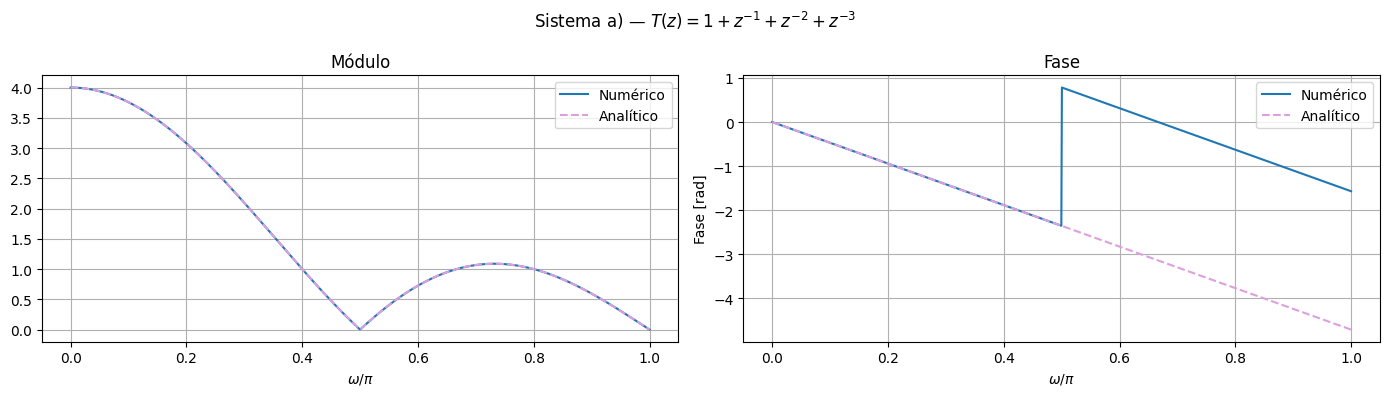

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sig

w = np.linspace(0, np.pi, 1000)
b_a = np.array([1, 1, 1, 1])
w_a, H_a = sig.freqz(b_a, [1], worN=w)

mod_a  = 2 * np.abs(np.cos(3*w/2) + np.cos(w/2))
fase_a = -3*w/2


fig, axes = plt.subplots(1, 2, figsize=(14, 4), tight_layout=True)
fig.suptitle(r"Sistema a) — $T(z) = 1 + z^{-1} + z^{-2} + z^{-3}$")

# módulo
axes[0].plot(w/np.pi, np.abs(H_a), label='Numérico')
axes[0].plot(w/np.pi, mod_a, '--', color= 'plum', label='Analítico')
axes[0].set_xlabel(r'$\omega / \pi$')
axes[0].set_title('Módulo')
axes[0].legend(); axes[0].grid(True)

# fase 
axes[1].plot(w/np.pi, np.unwrap(np.angle(H_a)), label='Numérico')
axes[1].plot(w/np.pi, fase_a,'--', color= 'plum', label='Analítico')
axes[1].set_xlabel(r'$\omega / \pi$')
axes[1].set_ylabel('Fase [rad]')
axes[1].set_title('Fase')
axes[1].legend(); axes[1].grid(True)

plt.show()

### Ejercicio B

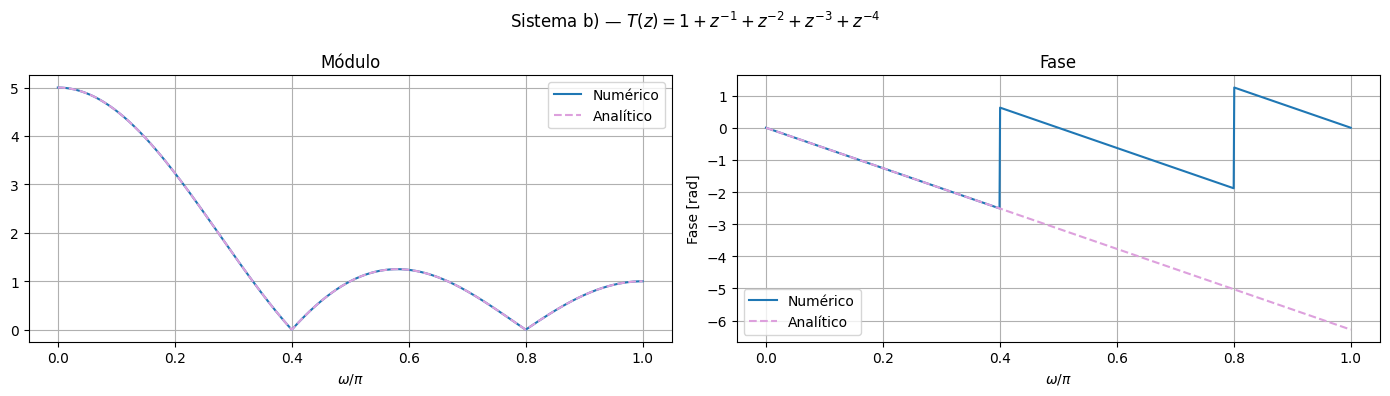

In [20]:
b_b = np.array([1, 1, 1, 1, 1])
w_b, H_b = sig.freqz(b_b, [1], worN=w)

mod_b  = np.abs(2*np.cos(2*w) + 2*np.cos(w) + 1)
fase_b = -2*w

fig, axes = plt.subplots(1, 2, figsize=(14, 4), tight_layout=True)
fig.suptitle(r"Sistema b) — $T(z) = 1 + z^{-1} + z^{-2} + z^{-3} + z^{-4}$")

# módulo
axes[0].plot(w/np.pi, np.abs(H_b), label='Numérico')
axes[0].plot(w/np.pi, mod_b, '--', color= 'plum', label='Analítico')
axes[0].set_xlabel(r'$\omega / \pi$')
axes[0].set_title('Módulo')
axes[0].legend(); axes[0].grid(True)

# fase
axes[1].plot(w/np.pi, np.unwrap(np.angle(H_b)), label='Numérico')
axes[1].plot(w/np.pi, fase_b, '--', color= 'plum', label='Analítico')
axes[1].set_xlabel(r'$\omega / \pi$')
axes[1].set_ylabel('Fase [rad]')
axes[1].set_title('Fase')
axes[1].legend(); axes[1].grid(True)

plt.show()

### Ejercicio C

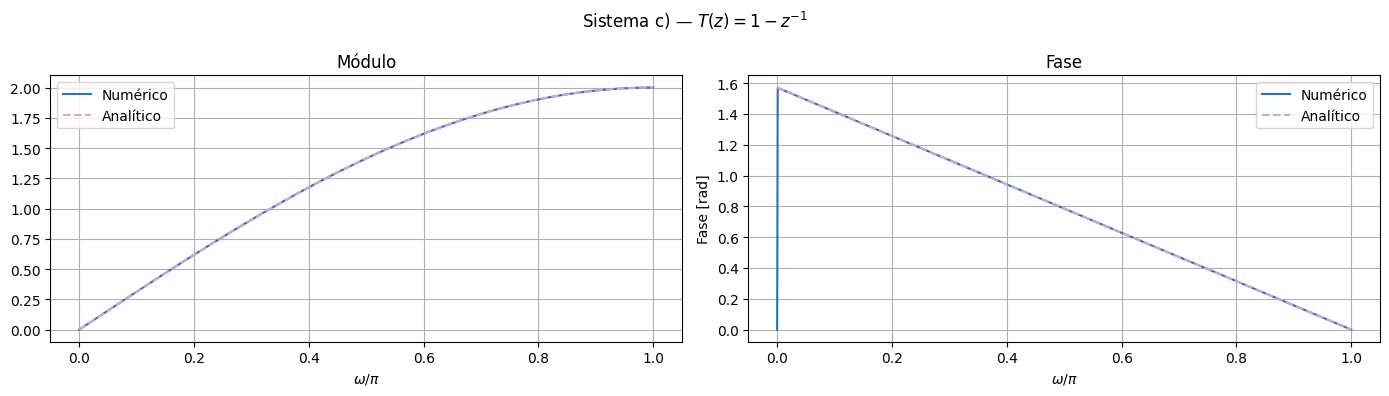

In [16]:
b_c = np.array([1, -1])
w_c, H_c = sig.freqz(b_c, [1], worN=w)

mod_c  = 2 * np.abs(np.sin(w/2))
fase_c = np.pi/2 - w/2

fig, axes = plt.subplots(1, 2, figsize=(14, 4), tight_layout=True)
fig.suptitle(r"Sistema c) — $T(z) = 1 - z^{-1}$")

# módulo
axes[0].plot(w/np.pi, np.abs(H_c), label='Numérico')
axes[0].plot(w/np.pi, mod_c, '--', color='plum', label='Analítico')
axes[0].set_xlabel(r'$\omega / \pi$')
axes[0].set_title('Módulo')
axes[0].legend(); axes[0].grid(True)

# fase 
axes[1].plot(w/np.pi, np.unwrap(np.angle(H_c)), label='Numérico')
axes[1].plot(w/np.pi, fase_c, '--', color='plum',label='Analítico')
axes[1].set_xlabel(r'$\omega / \pi$')
axes[1].set_ylabel('Fase [rad]')
axes[1].set_title('Fase')
axes[1].legend(); axes[1].grid(True)

plt.show()

### Ejercicio C

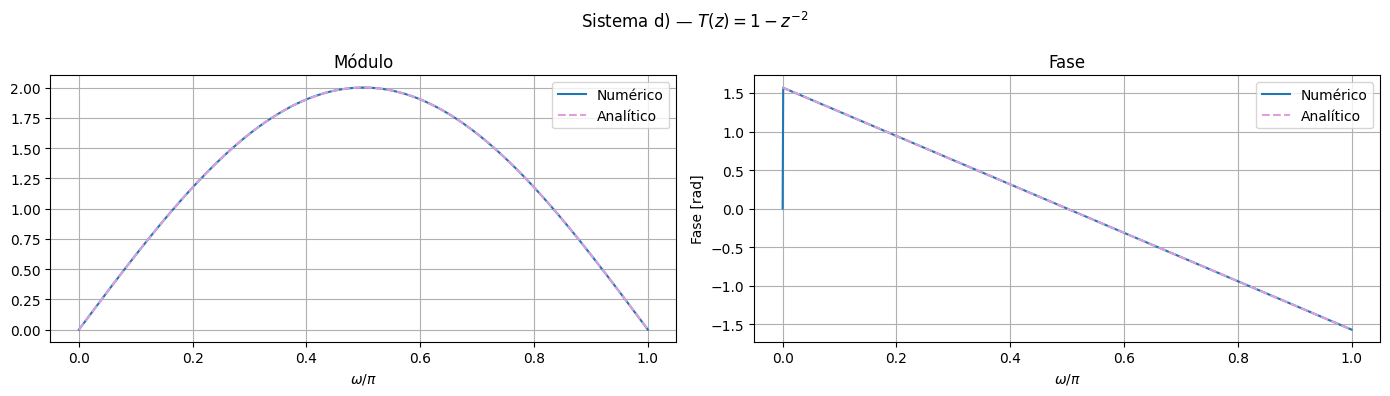

In [19]:
b_d = np.array([1, 0, -1])
w_d, H_d = sig.freqz(b_d, [1], worN=w)

mod_d  = 2 * np.abs(np.sin(w))
fase_d = np.pi/2 - w

fig, axes = plt.subplots(1, 2, figsize=(14, 4), tight_layout=True)
fig.suptitle(r"Sistema d) — $T(z) = 1 - z^{-2}$")

# módulo
axes[0].plot(w/np.pi, np.abs(H_d), label='Numérico')
axes[0].plot(w/np.pi, mod_d, '--', color='plum',label='Analítico')
axes[0].set_xlabel(r'$\omega / \pi$')
axes[0].set_title('Módulo')
axes[0].legend(); axes[0].grid(True)

# fase 
axes[1].plot(w/np.pi, np.unwrap(np.angle(H_d)), label='Numérico')
axes[1].plot(w/np.pi, fase_d, '--', color='plum',label='Analítico')
axes[1].set_xlabel(r'$\omega / \pi$')
axes[1].set_ylabel('Fase [rad]')
axes[1].set_title('Fase')
axes[1].legend(); axes[1].grid(True)

plt.show()


## Comparación de los cuatro sistemas

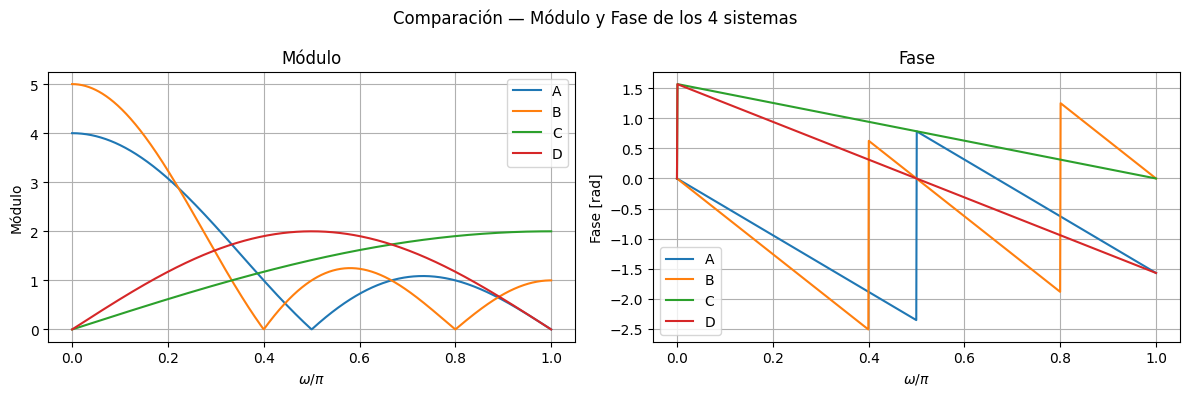

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), tight_layout=True)
fig.suptitle("Comparación — Módulo y Fase de los 4 sistemas")

ax1.plot(w/np.pi, np.abs(H_a),label='A')
ax1.plot(w/np.pi, np.abs(H_b),label='B')
ax1.plot(w/np.pi, np.abs(H_c),label='C')
ax1.plot(w/np.pi, np.abs(H_d),label='D')
ax1.set_xlabel(r'$\omega / \pi$')
ax1.set_ylabel('Módulo')
ax1.set_title('Módulo')
ax1.legend();
ax1.grid(True)

ax2.plot(w/np.pi, np.unwrap(np.angle(H_a)), label='A')
ax2.plot(w/np.pi, np.unwrap(np.angle(H_b)),label='B')
ax2.plot(w/np.pi, np.unwrap(np.angle(H_c)),label='C')
ax2.plot(w/np.pi, np.unwrap(np.angle(H_d)),label='D')
ax2.set_xlabel(r'$\omega / \pi$')
ax2.set_ylabel('Fase [rad]')
ax2.set_title('Fase')
ax2.legend()
ax2.grid(True)

plt.show()


# CONCLUSIÓN
A partir de las respuestas en frecuencia obtenidas, se observa que los sistemas A y B se comportan como filtros pasa-bajos.

El sistema B, al tener una mayor cantidad de muestras que el sistema A, al promediar más valores de la señal, atenúa con mayor fuerza las variaciones rápidas, que son las asociadas a altas frecuencias.

Por otro lado, el sistema C se comporta como un filtro pasa-altos, ya que realiza la diferencia entre la muestra actual y la muestra anterior. Esto hace que las señales constantes o de baja frecuencia se cancelen, mientras que las variaciones rápidas de la señal se resaltan.

El sistema D presenta una anulación en baja frecuencia y también en la frecuencia máxima, por lo que puede interpretarse como un comportamiento pasa-banda, dejando pasar principalmente componentes intermedias.

Finalmente, todos los sistemas analizados son filtros FIR, ya que la salida depende solamente de valores actuales y pasados de la entrada, y no de salidas anteriores. Además, presentan fase lineal: los sistemas A y B tienen coeficientes simétricos, mientras que los sistemas C y D tienen coeficientes antisimétricos. 